In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
import umap

d:\final_facenet\env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = load_model(r'D:\final_facenet\model\CA_70EA_70$$C078_E065.h5')
datatestnocrop = r"D:\InceptionNet\DATATEST100 class\100classtestnocrop"

In [3]:
def loadimage(image_path):
    try:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (224, 224))
        img = tf.cast(img, tf.float32)
        img = img / 255.0  # Normalization
        img = tf.clip_by_value(img, 0.0, 1.0)#img = tf.where(tf.math.is_finite(img), img, tf.zeros_like(img)) # แทนที่ค่า NaN หรือ Inf ด้วย 0
        img.set_shape((224, 224, 3))
        return img
    except:
        print(f"Error loading image {image_path}. Returning a zero tensor.")
        return tf.zeros((224, 224, 3), dtype=tf.float32)

In [4]:
def loadimageD1(image_path):
    try:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (224, 224))
        img = tf.cast(img, tf.float32)
        img = (img - 127.5) / 128.0  # Normalization
        img = tf.expand_dims(img, axis=0)
        img.set_shape((1, 224, 224, 3))
        return img
    except:
        print(f"Error loading image {image_path}. Returning a zero tensor.")
        return tf.zeros((1, 224, 224, 3), dtype=tf.float32)

In [5]:
def load_image_facenet_prewhiten(image_path):
    try:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (224, 224))
        img = tf.cast(img, tf.float32) 
        mean = tf.reduce_mean(img)
        stddev = tf.math.reduce_std(img)
        stddev_adj = tf.maximum(stddev, 1.0 / tf.sqrt(tf.cast(tf.size(img), tf.float32)))
        img = (img - mean) / stddev_adj
        img = tf.expand_dims(img, axis=0)
        return img
    except Exception as e:
        print(f"Error loading image {image_path}. Error: {e}")
        return tf.zeros((224, 224, 3), dtype=tf.float32)

In [6]:
pat = os.listdir(datatestnocrop)
print(len(pat))

101


In [14]:
cosine_similarities = []
for i in os.listdir(datatestnocrop):
    cosine_similarities.append(i)
    #print(i)

In [17]:
print(len(cosine_similarities))
print(type(cosine_similarities[5]))

101
<class 'str'>


In [7]:
testdata = r"D:\final_facenet\testdataset"

In [8]:
print(type(testdata))

<class 'str'>


In [12]:
all_images = []
i = 0

# loop โฟลเดอร์แต่ละคน
for person_folder in os.listdir(testdata):
    i += 1
    print(person_folder)

print(i)


1064
1074
2003
4059
8966
9322
6


In [10]:
all_images = []

# loop โฟลเดอร์แต่ละคน
for person_folder in os.listdir(testdata):
    person_path = os.path.join(testdata, person_folder)
    if os.path.isdir(person_path):  # เช็คว่าเป็นโฟลเดอร์
        # loop รูปในโฟลเดอร์คนนี้
        for img_file in os.listdir(person_path):
            img_path = os.path.join(person_path, img_file)
            if os.path.isfile(img_path):
                all_images.append(img_path)

print(all_images)


['D:\\final_facenet\\testdataset\\1064\\72965.jpg', 'D:\\final_facenet\\testdataset\\1064\\72966.jpg', 'D:\\final_facenet\\testdataset\\1064\\72967.jpg', 'D:\\final_facenet\\testdataset\\1064\\72968.jpg', 'D:\\final_facenet\\testdataset\\1064\\72969.jpg', 'D:\\final_facenet\\testdataset\\1064\\72970.jpg', 'D:\\final_facenet\\testdataset\\1064\\72971.jpg', 'D:\\final_facenet\\testdataset\\1064\\72972.jpg', 'D:\\final_facenet\\testdataset\\1064\\72973.jpg', 'D:\\final_facenet\\testdataset\\1064\\72974.jpg', 'D:\\final_facenet\\testdataset\\1064\\72975.jpg', 'D:\\final_facenet\\testdataset\\1064\\72976.jpg', 'D:\\final_facenet\\testdataset\\1064\\72977.jpg', 'D:\\final_facenet\\testdataset\\1064\\72978.jpg', 'D:\\final_facenet\\testdataset\\1064\\72979.jpg', 'D:\\final_facenet\\testdataset\\1064\\72980.jpg', 'D:\\final_facenet\\testdataset\\1064\\72981.jpg', 'D:\\final_facenet\\testdataset\\1064\\72982.jpg', 'D:\\final_facenet\\testdataset\\1064\\72983.jpg', 'D:\\final_facenet\\testdatase

In [11]:
f = "s5d"
tesp = os.path.join(testdata, f)
print(tesp)

D:\final_facenet\testdataset\s5d


In [12]:
list_imaegs = []

for person in os.listdir(datatestnocrop):
    person_path = os.path.join(datatestnocrop, person)
    if os.path.isdir(person_path):
        for img_file in os.listdir(person_path):
            img_path = os.path.join(person_path, img_file)
            if os.path.isfile(img_path): # เช็คว่าเป็นไฟล์รูป
                print(img_path)
                list_imaegs.append(img_path)

D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192793.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192794.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192795.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192796.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192797.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192798.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192799.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192800.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192801.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192802.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192803.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192804.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192805.jpg
D:\InceptionNet\DATATEST100 class\100classtestnocrop\101680\6192

In [18]:
datatest6class = r'D:\final_facenet\testdataset'

In [19]:
import os

images_by_person = {}

def load_images_by_person(image):
    images_by_person = {}
    for person in os.listdir(image):
        person_path = os.path.join(datatestnocrop, person)
        if os.path.isdir(person_path):
            person_images = []  # list สำหรับรูปของคนนี้
            for img_file in os.listdir(person_path):
                img_path = os.path.join(person_path, img_file)
                if os.path.isfile(img_path):
                    person_images.append(img_path)
            if len(person_images) > 2:
                images_by_person[person] = person_images  # เก็บใน dict
    return images_by_person

data = load_images_by_person(datatest6class)
print(data)
print(type(data))
print(len(data))


{'1064': ['D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72965.jpg', 'D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72966.jpg', 'D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72967.jpg', 'D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72968.jpg', 'D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72969.jpg', 'D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72970.jpg', 'D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72971.jpg', 'D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72972.jpg', 'D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72973.jpg', 'D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72974.jpg', 'D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72975.jpg', 'D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72976.jpg', 'D:\\InceptionNet\\DATATEST100 class\\100classtestnocrop\\1064\\72977.jpg', 'D

In [34]:
cosine_similarities = []
ecudes_distances = []

for img_path in data:
    print(img_path)
    for ref_img_path in all_images:
        print(ref_img_path)


1064
D:\final_facenet\testdataset\1064\72965.jpg
D:\final_facenet\testdataset\1064\72966.jpg
D:\final_facenet\testdataset\1064\72967.jpg
D:\final_facenet\testdataset\1064\72968.jpg
D:\final_facenet\testdataset\1064\72969.jpg
D:\final_facenet\testdataset\1064\72970.jpg
D:\final_facenet\testdataset\1064\72971.jpg
D:\final_facenet\testdataset\1064\72972.jpg
D:\final_facenet\testdataset\1064\72973.jpg
D:\final_facenet\testdataset\1064\72974.jpg
D:\final_facenet\testdataset\1064\72975.jpg
D:\final_facenet\testdataset\1064\72976.jpg
D:\final_facenet\testdataset\1064\72977.jpg
D:\final_facenet\testdataset\1064\72978.jpg
D:\final_facenet\testdataset\1064\72979.jpg
D:\final_facenet\testdataset\1064\72980.jpg
D:\final_facenet\testdataset\1064\72981.jpg
D:\final_facenet\testdataset\1064\72982.jpg
D:\final_facenet\testdataset\1064\72983.jpg
D:\final_facenet\testdataset\1064\72984.jpg
D:\final_facenet\testdataset\1064\72985.jpg
D:\final_facenet\testdataset\1064\72986.jpg
D:\final_facenet\testdatase

In [19]:
print("Cosine Similarities:", cosine_similarities)
print("Euclidean Distances:", ecudes_distances)

Cosine Similarities: []
Euclidean Distances: []


In [ ]:
def loadimage(image_path):
    try:
        img = tf.io.read_file(image_path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (224, 224))
        img = tf.cast(img, tf.float32)
        img = img / 255.0  # Normalization
        img = tf.clip_by_value(img, 0.0, 1.0)#img = tf.where(tf.math.is_finite(img), img, tf.zeros_like(img)) # แทนที่ค่า NaN หรือ Inf ด้วย 0
        img.set_shape((224, 224, 3))
        return img
    except:
        print(f"Error loading image {image_path}. Returning a zero tensor.")
        return tf.zeros((224, 224, 3), dtype=tf.float32)

In [47]:
def images_to_embeddings(images_by_person, model):
    embeddings = []
    labels = []

    for person, img_paths in images_by_person.items():
        for img_path in img_paths:
            # โหลดภาพและเตรียม input
            img = image.load_img(img_path, target_size=(224, 224))  # ปรับตามโมเดลของคุณ
            x = image.img_to_array(img)
            x = x / 255.0  # normalization เหมือนที่ใช้ตอนเทรน
            x = np.expand_dims(x, axis=0)

            # พยากรณ์ embedding
            emb = model.predict(x)
            emb = emb.flatten()
            embeddings.append(emb)
            labels.append(person)

    return np.vstack(embeddings), np.array(labels)

In [48]:
def plot_embeddings_tsne_umap(embeddings, labels, save_path=None):
    le = LabelEncoder()
    y = le.fit_transform(labels)

    # --- t-SNE ---
    tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
    print("🔹 กำลังคำนวณ t-SNE ...")
    z_tsne = tsne.fit_transform(embeddings)

    # --- UMAP ---
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
    print("🔹 กำลังคำนวณ UMAP ...")
    z_umap = reducer.fit_transform(embeddings)

    # --- วาดกราฟ ---
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    cmap = plt.get_cmap("tab20")

    for ax, z, title in zip(axs, [z_tsne, z_umap], ["t-SNE", "UMAP"]):
        scatter = ax.scatter(z[:, 0], z[:, 1], c=y, cmap=cmap, s=20)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200)
        print(f"💾 บันทึกกราฟที่: {save_path}")

    plt.show()

✅ โหลดโมเดลสำเร็จ!
พบ 101 คลาสที่มีภาพ > 2
1/1 [==============================] - 0s 61ms/step
✅ สร้าง embeddings แล้ว: (6692, 128)
🔹 กำลังคำนวณ t-SNE ...
🔹 กำลังคำนวณ UMAP ...


d:\final_facenet\env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\final_facenet\env\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


💾 บันทึกกราฟที่: tsne_umap_plot.png


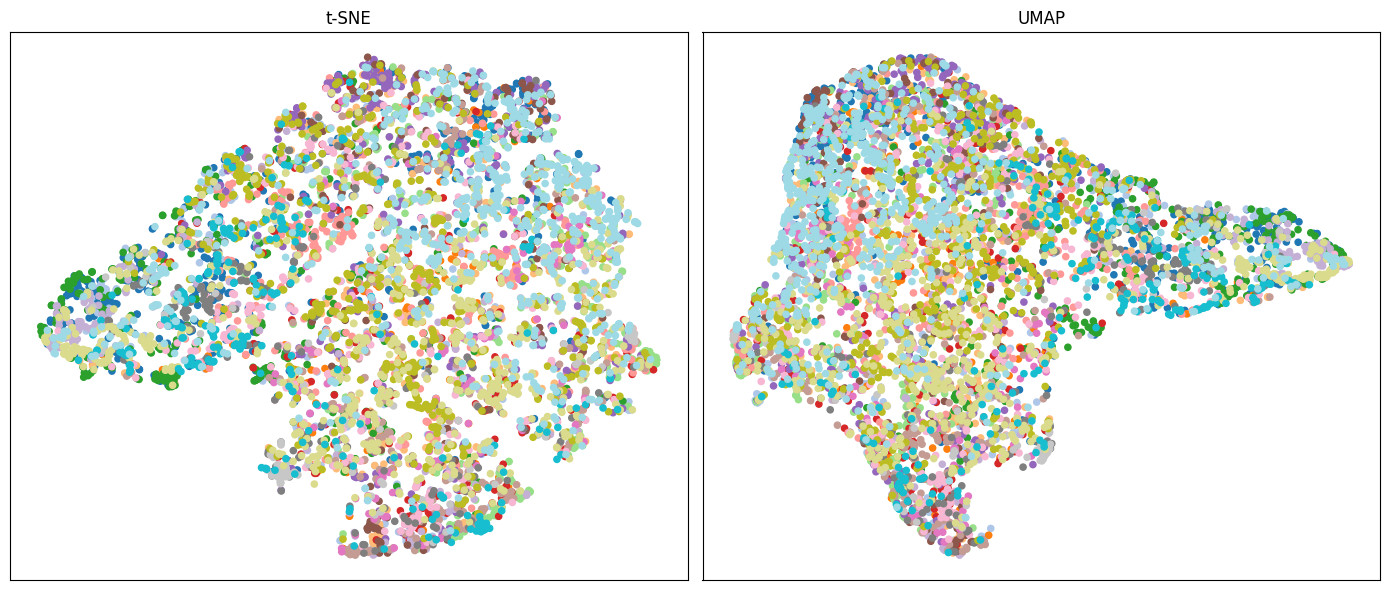

In [51]:
# 🔹 กำหนดพาธของโมเดลและโฟลเดอร์ภาพ
model_path = r"D:\final_facenet\model\CA_076EA_078$$C078_E065Over.h5"         # ← เปลี่ยนชื่อไฟล์โมเดลของคุณ
data_folder = r"D:\InceptionNet\DATATEST100 class\100classtestnocrop" # ← เปลี่ยนพาธโฟลเดอร์ภาพของคุณ

# โหลดโมเดล
model = load_model(model_path)
print("✅ โหลดโมเดลสำเร็จ!")

# โหลดภาพ
images_by_person = load_images_by_person(data_folder)
print(f"พบ {len(images_by_person)} คลาสที่มีภาพ > 2")

# แปลงภาพทั้งหมดเป็น embeddings
embeddings, labels = images_to_embeddings(images_by_person, model)
print(f"✅ สร้าง embeddings แล้ว: {embeddings.shape}")

# วาดกราฟ
plot_embeddings_tsne_umap(embeddings, labels, save_path="tsne_umap_plot.png")